## Imports

In [2]:
import json
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

## Load scores and plotting metadata

In [3]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/essential_lfc.csv", index_col=0)

In [4]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = fig_index["fusion"]
model_type_palette = fig_index['genes_model_type_palette']
hue_order = fig_index['genes_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({"font.size": 13})
mpl.rcParams.update({"xtick.labelsize": 13})
mpl.rcParams.update({"ytick.labelsize": 13})

## Multi-cell line plot

K-562
	train mean: 4.958851881410832
	exp err: 4.570094505703786
	viable range: 0.3887573757070468
	unimodal delta: 0.29854261370971535
	unimodal delta ratio: 0.7679407063769409
	simple fusion delta: 0.3158862766365118
	simple fusion delta ratio: 0.8125537838658321
	simple fusion excess delta ratio: 0.044613077488891206
	full fusion delta: 0.39740920864015195
	full fusion delta ratio: 1.022255096555711
	full fusion excess delta ratio: 0.25431439017877
Hep-G2
	train mean: 7.088296665452211
	exp err: 6.440344860875873
	viable range: 0.6479518045763379
	unimodal delta: 0.4002027608470691
	unimodal delta ratio: 0.6176427907454334
	simple fusion delta: 0.4609580990462563
	simple fusion delta ratio: 0.7114080025560742
	simple fusion excess delta ratio: 0.09376521181064079
	full fusion delta: 0.5576302131704791
	full fusion delta ratio: 0.8606044604429871
	full fusion excess delta ratio: 0.24296166969755373
Jurkat
	train mean: 6.528218630411582
	exp err: 6.344629938378517
	viable range: 0.183

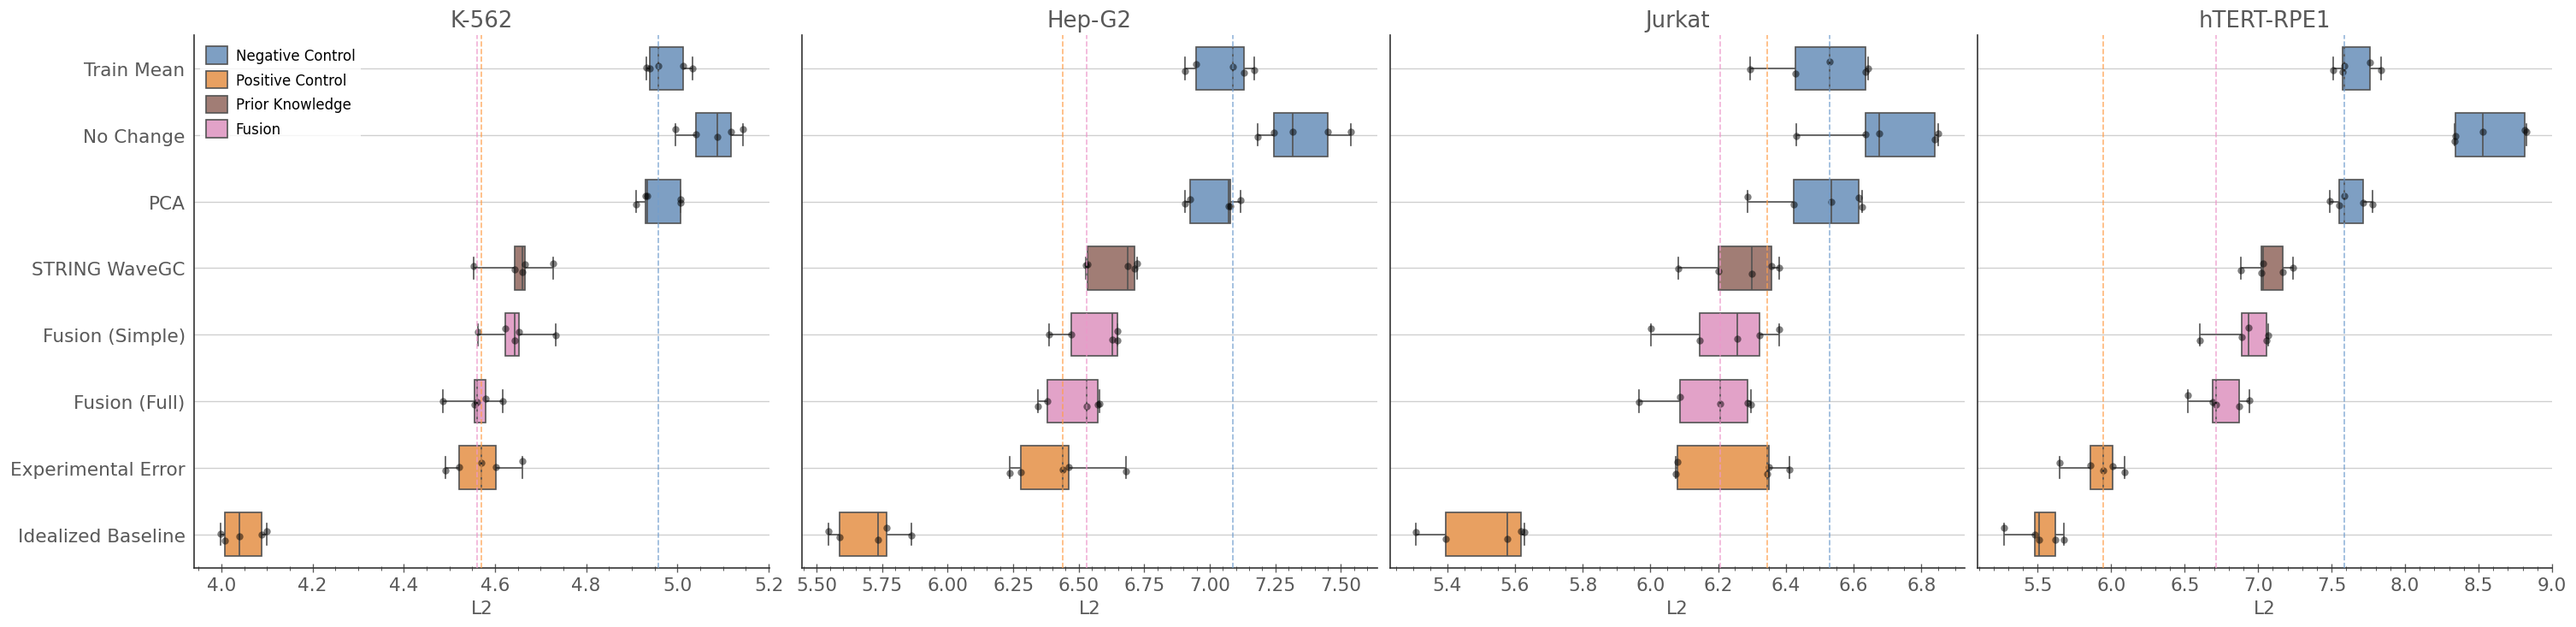

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(25, 6), constrained_layout=True)
for i, cell_line in enumerate(["K-562", "Hep-G2", "Jurkat", "hTERT-RPE1"]):

    # Build the dataframe
    method_list = [e.replace("CELL_LINE", cell_line) for e in method_map]
    idx = df["fold"].str.contains(cell_line) & df["name"].isin(method_list)
    df_subset = df[idx].copy()
    df_subset["name"] = df_subset["name"].str.replace(cell_line, "CELL_LINE")
    df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
    df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

    # Boxplot
    g = sns.boxplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        hue="Model type",
        x="L2",
        ax=axes[i],
        whis=(0, 100),
        width=0.65, 
        palette=model_type_palette
    )

    # Overlay datapoints
    sns.stripplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        color="black",
        alpha=0.5,
        x="L2",
        ax=axes[i],
    )

    # Decorate
    g.grid(axis="y")
    g.set(ylabel=None, title=cell_line)
    g.legend(title=None)
    if i > 0:
        g.set(yticklabels=[])
        g.legend().remove()
    
    # Get the best model
    best_mask = (
        (df_subset["Model type"] == "Fusion")
    )
    best_group = (
        df_subset.loc[best_mask]
        .groupby("name")["L2"]
        .median()
    )
    best_name = best_group.idxmin()
    best_level = best_group.loc[best_name]
    best_model_type = (
        df_subset.loc[df_subset["name"] == best_name, "Model type"]
        .iloc[0]
    )

    # Draw vertical lines
    train_mean_level = df_subset[df_subset["name"] == "Train Mean"]["L2"].median()
    simple_fusion_level = df_subset[df_subset["name"] == "Fusion (Simple)"]["L2"].median()
    full_fusion_level = df_subset[df_subset["name"] == "Fusion (Full)"]["L2"].median()
    unimodal_level = df_subset[df_subset["name"] == "STRING WaveGC"]["L2"].median()
    g.axvline(train_mean_level, color=model_type_palette["Negative Control"], linestyle="--", linewidth=1, zorder=99, alpha=.75)
    exp_err_level = df_subset[df_subset["name"] == f"Experimental Error"]["L2"].median()
    g.axvline(exp_err_level, color=model_type_palette["Positive Control"], linestyle="--", linewidth=1, zorder=99, alpha=.75)
    g.axvline(best_level, color=model_type_palette[best_model_type], linestyle="--", linewidth=1, zorder=99, alpha=.75)

    print(cell_line)

    print(f"\ttrain mean: {train_mean_level}")
    print(f"\texp err: {exp_err_level}")
    viable = train_mean_level - exp_err_level
    print(f"\tviable range: {viable}")

    achieved_unimodal = train_mean_level - unimodal_level
    print(f"\tunimodal delta: {achieved_unimodal}")
    print(f"\tunimodal delta ratio: {achieved_unimodal / viable}")

    achieved_simple = train_mean_level - simple_fusion_level
    print(f"\tsimple fusion delta: {achieved_simple}")
    print(f"\tsimple fusion delta ratio: {achieved_simple / viable}")
    print(
        f"\tsimple fusion excess delta ratio: {achieved_simple / viable - achieved_unimodal / viable}"
    )

    achieved_full = train_mean_level - full_fusion_level
    print(f"\tfull fusion delta: {achieved_full}")
    print(f"\tfull fusion delta ratio: {achieved_full / viable}")
    print(
        f"\tfull fusion excess delta ratio: {achieved_full / viable - achieved_unimodal / viable}"
    )
plt.savefig("fig_5.pdf")